# S1-DS-05/06 — Cohort and Temporal Protocol

`S1-DS-04` measured the raw data. This task turns those measurements into the **causal data
protocol** every later task depends on.

## What this notebook decides

1. **What a logical session is** — and how the two null-session rows are handled.
2. **The chronological Train / Validation / Test protocol**, as half-open UTC intervals.
3. **Who is eligible for the training cohort**, using TRAIN-only information.
4. **What happens to sessions that cross a split boundary**, and to outcomes that are not
   yet observable.

## What it does not decide

No `T1`/`T2`/`T3` labels, no candidate generation, no features, no metrics, no client
assignment. Those belong to the TaskExample builders that come next.

## The one correction carried in from S1-DS-04

The earlier cohort draft used **elapsed span** (`last_seen - first_seen`) as an eligibility
condition. `S1-DS-04` showed span and real activity are not interchangeable: a user seen on
1 and 31 October has a 30-day span but only 2 active dates. Eligibility here uses
**distinct active calendar dates inside TRAIN**. Span is not used as a hidden condition.

In [1]:
"""S1-DS-05/06: session policy, temporal split, and TRAIN-only cohort selection."""

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

TASK_DIR = Path.cwd()
PROJECT_DIR = TASK_DIR.parent
SOURCE_PARQUET = PROJECT_DIR / "Dataset" / "processed_raw_parquet_v1.parquet"
AUDIT_JSON = PROJECT_DIR / "S1-DS-04_Data_Audit" / "output" / "data_audit_pass1.json"
OUTPUT_DIR = TASK_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

config = json.loads((TASK_DIR / "config.json").read_text(encoding="utf-8"))

parquet = pq.ParquetFile(SOURCE_PARQUET)
TOTAL_ROWS = parquet.metadata.num_rows
ROW_GROUPS = parquet.metadata.num_row_groups

print("Source :", SOURCE_PARQUET.name)
print(f"Rows   : {TOTAL_ROWS:,}")
print(f"Groups : {ROW_GROUPS}")

Source : processed_raw_parquet_v1.parquet
Rows   : 42,448,764
Groups : 85


## 1. Verify the input against S1-DS-04

Minimal reconciliation only. If the row count, the event vocabulary or the date range
disagrees with the audit, this notebook is reading a different file and nothing below is valid.

In [2]:
audit = json.loads(AUDIT_JSON.read_text(encoding="utf-8"))

audit_rows = audit["rows_audited"]
audit_users = audit["dataset_totals"]["Unique users"]
audit_sessions = audit["dataset_totals"]["Unique sessions"]
audit_events = {k: int(v) for k, v in audit["event_types"].items()}
audit_null_sessions = audit["missingness"]["user_session"]["rows"]

print(f"Audit rows      : {audit_rows:,}")
print(f"Parquet rows    : {TOTAL_ROWS:,}")
print(f"Audit users     : {audit_users:,}")
print(f"Audit sessions  : {audit_sessions:,}")
print(f"Event vocabulary: {sorted(audit_events)}")
print(f"Null sessions   : {audit_null_sessions}")
print(f"Date range      : {audit['time_coverage']['first_timestamp']}"
      f" to {audit['time_coverage']['last_timestamp']}")

assert TOTAL_ROWS == audit_rows, "row count disagrees with S1-DS-04"
assert sorted(audit_events) == ["cart", "purchase", "view"], "unexpected event vocabulary"
print()
print("Input reconciles with the audit.")

Audit rows      : 42,448,764
Parquet rows    : 42,448,764
Audit users     : 3,022,290
Audit sessions  : 9,244,772
Event vocabulary: ['cart', 'purchase', 'view']
Null sessions   : 2
Date range      : 2019-10-01 00:00:00+00:00 to 2019-10-31 23:59:59+00:00

Input reconciles with the audit.


## 2. Session policy

**The raw `user_session` string is not a safe key on its own.** The same raw value appears
under different users, so keying on it alone would merge two people into one session. The
logical session is therefore the pair `(user_id, user_session)`.

**Provided sessions are preserved.** REES46 supplies the session boundary and we keep it. We
do not rebuild every session with a 30-minute inactivity rule: that would silently overwrite
source semantics across the whole dataset without evidence that it is better.

**Null sessions become singletons.** Only 2 rows in 42.4 million have no session. Each becomes
its own session, keyed by provenance, so it can never be merged into a real session.

In [3]:
NULL_SESSION_PREFIX = config["session_policy"]["null_fallback_prefix"]


def logical_session_key(chunk):
    """One 64-bit key per logical session.

    Provided sessions are keyed by (user_id, user_session) so the same raw string
    under two users stays two sessions. A null session becomes a singleton keyed by
    its own row, which cannot collide with any provided session.
    """
    user = chunk["user_id"].astype(str)
    session = chunk["user_session"]

    provided = pd.util.hash_pandas_object(user + "|" + session.astype(str), index=False)
    singleton = pd.util.hash_pandas_object(
        NULL_SESSION_PREFIX + "|" + user + "|" + chunk["source_row_number"].astype(str),
        index=False)

    return provided.where(session.notna(), singleton)

## 3. Temporal split

Four half-open UTC intervals, `[start, end)`. An event falling exactly on a cutoff belongs to
the interval on the **right**, so no event can land in two intervals and none can be lost.

`LABEL_GRACE` is **observation only**. It exists so a decision taken on 30 October can still
have its outcome observed. It never creates a new evaluation decision.

In [4]:
SPLITS = [(name, pd.Timestamp(start, tz="UTC"), pd.Timestamp(end, tz="UTC"))
          for name, (start, end) in config["temporal_split"].items()]
SPLIT_NAMES = [name for name, _, _ in SPLITS]
DECISION_SPLITS = config["decision_splits"]   # grace is deliberately excluded


def assign_split(times):
    """Half-open interval assignment; -1 means the event fell outside every interval."""
    codes = np.full(len(times), -1, dtype="int8")
    for code, (_, start, end) in enumerate(SPLITS):
        codes[(times >= start) & (times < end)] = code
    return codes


for name, start, end in SPLITS:
    days = (end - start).days
    decision = "decisions" if name in DECISION_SPLITS else "observation only"
    print(f"{name:12} [{start.date()} , {end.date()})  {days:>2} days   {decision}")

TRAIN        [2019-10-01 , 2019-10-22)  21 days   decisions
VALIDATION   [2019-10-22 , 2019-10-27)   5 days   decisions
TEST         [2019-10-27 , 2019-10-31)   4 days   decisions
LABEL_GRACE  [2019-10-31 , 2019-11-01)   1 days   observation only


## 4. One pass over the data

Everything below is collected in one chunked pass. What is accumulated:

- which splits each logical session touches — enough to detect boundary crossings
- each user's earliest split — enough to classify who is new in Validation or Test
- TRAIN-only events, sessions and distinct active dates per user — the cohort inputs
- TRAIN purchasers, for the diagnostic column only

Nothing is sampled. A second pass later measures the boundary-exclusion cost; those are the
only two passes over the data.

In [5]:
COLUMNS = ["event_time", "event_type", "user_id", "user_session", "source_row_number"]

session_split_parts = []    # unique (session, split) pairs -> boundary crossing
train_user_events = pd.Series(dtype="int64")
train_user_session_parts = []   # unique (user, session) inside TRAIN
train_user_date_parts = []      # unique (user, date)  inside TRAIN
first_split = pd.Series(dtype="int8")

composite_session_keys = set()
raw_owner_parts = []            # unique (raw session, user) pairs -> reused raw ids
train_purchasers = set()        # diagnostic only, never part of eligibility

split_rows = np.zeros(len(SPLITS), dtype="int64")
rows_seen = 0
null_session_rows = 0

for group in range(ROW_GROUPS):
    chunk = parquet.read_row_group(group, columns=COLUMNS).to_pandas()
    rows_seen += len(chunk)

    user = chunk["user_id"].astype("int64")
    times = chunk["event_time"]
    session = logical_session_key(chunk)
    split = assign_split(times)

    np.add.at(split_rows, split[split >= 0], 1)
    null_session_rows += int(chunk["user_session"].isna().sum())

    # the earliest split a user appears in; the file is time ordered so the held value wins
    chunk_first = pd.Series(split, index=user).groupby(level=0).min()
    first_split = first_split.combine_first(chunk_first) if len(first_split) else chunk_first

    session_split_parts.append(
        pd.DataFrame({"session": session.to_numpy(), "split": split}).drop_duplicates())

    # Only real raw ids take part in this diagnostic. Null sessions have no raw value,
    # and casting them to a string would count one shared "nan" as a reused id.
    has_raw_session = chunk["user_session"].notna().to_numpy()
    if has_raw_session.any():
        raw_key = pd.util.hash_pandas_object(
            chunk.loc[has_raw_session, "user_session"], index=False)
        raw_owner_parts.append(pd.DataFrame(
            {"raw": raw_key.to_numpy(), "user": user[has_raw_session].to_numpy()}
        ).drop_duplicates())

    in_train = split == SPLIT_NAMES.index("TRAIN")
    if in_train.any():
        train_user_events = train_user_events.add(
            user[in_train].value_counts(), fill_value=0)
        train_user_session_parts.append(pd.DataFrame({
            "user": user[in_train].to_numpy(),
            "session": session[in_train].to_numpy()}).drop_duplicates())
        train_user_date_parts.append(pd.DataFrame({
            "user": user[in_train].to_numpy(),
            "date": times[in_train].dt.normalize().to_numpy()}).drop_duplicates())

        # purchase reach is a diagnostic; collecting it here avoids a second full pass
        bought = in_train & (chunk["event_type"] == "purchase").to_numpy()
        if bought.any():
            train_purchasers.update(user[bought].unique())

    composite_session_keys.update(session.unique())

    if (group + 1) % 20 == 0:
        print(f"  {group + 1}/{ROW_GROUPS} row groups")

assert rows_seen == TOTAL_ROWS, "the pass did not cover every row"
assert int(split_rows.sum()) == TOTAL_ROWS, "some events fell outside every interval"
print()
print(f"Rows processed: {rows_seen:,}")

  20/85 row groups


  40/85 row groups


  60/85 row groups


  80/85 row groups



Rows processed: 42,448,764


In [6]:
# Collapse the per-chunk parts once.
session_splits = pd.concat(session_split_parts, ignore_index=True).drop_duplicates()
train_sessions = pd.concat(train_user_session_parts, ignore_index=True).drop_duplicates()
train_dates = pd.concat(train_user_date_parts, ignore_index=True).drop_duplicates()

train_user_events = train_user_events.astype("int64")
train_user_sessions = train_sessions.groupby("user").size()
train_user_active_days = train_dates.groupby("user").size()
first_split = first_split.astype("int8")

raw_owners = pd.concat(raw_owner_parts, ignore_index=True).drop_duplicates()
users_per_raw_key = raw_owners.groupby("raw")["user"].nunique()
reused_raw_keys = int((users_per_raw_key > 1).sum())
raw_session_keys = len(users_per_raw_key)   # distinct non-null raw values

del session_split_parts, train_user_session_parts, train_user_date_parts
del train_sessions, train_dates, raw_owner_parts, raw_owners, users_per_raw_key

split_summary = pd.DataFrame({
    "split": SPLIT_NAMES,
    "events": split_rows,
    "percent": (split_rows / TOTAL_ROWS * 100).round(2),
})
print(split_summary.to_string(index=False))
print()
print(f"Logical sessions        : {len(composite_session_keys):,}")
print(f"Raw session values (non-null)        : {raw_session_keys:,}")
print(f"Raw values used by more than one user: {reused_raw_keys:,}")
print(f"Users observed in TRAIN : {len(train_user_events):,}")

      split   events  percent
      TRAIN 29218702    68.83
 VALIDATION  6897095    16.25
       TEST  5087488    11.99
LABEL_GRACE  1245479     2.93

Logical sessions        : 9,244,772
Raw session values (non-null)        : 9,244,421
Raw values used by more than one user: 348
Users observed in TRAIN : 2,312,200


## 5. Boundary sessions

A logical session can straddle a cutoff. The policy is to **exclude the whole session** from
decision building when it crosses `TRAIN→VALIDATION` or `VALIDATION→TEST`.

The alternatives are worse. Splitting the session in half changes what a session means.
Assigning the whole thing to the earlier split leaks later behaviour into training.

`TEST→LABEL_GRACE` is **not** treated as a crossing: a test session is allowed to continue
into 31 October so an earlier decision can mature. Grace still starts no new decision.

In [7]:
train_code = SPLIT_NAMES.index("TRAIN")
val_code = SPLIT_NAMES.index("VALIDATION")
test_code = SPLIT_NAMES.index("TEST")
grace_code = SPLIT_NAMES.index("LABEL_GRACE")

# A session is judged on the full set of intervals it touches, not only its
# decision intervals. A session with an event in TRAIN and another in LABEL_GRACE
# jumped over both decision cutoffs even though it touches one decision interval,
# so filtering grace away before counting would let it through.
ALLOWED_PATTERNS = {
    (train_code,), (val_code,), (test_code,), (grace_code,),
    (test_code, grace_code),          # a test session may mature into label grace
}

session_patterns = (session_splits.groupby("session")["split"]
                    .apply(lambda values: tuple(sorted(set(values)))))
crossing_sessions = set(session_patterns[~session_patterns.isin(ALLOWED_PATTERNS)].index)

total_sessions = len(composite_session_keys)
readable = session_patterns.apply(lambda p: " + ".join(SPLIT_NAMES[i] for i in p))

print("Every split-touch pattern in the data:")
summary = pd.DataFrame({"sessions": readable.value_counts()})
summary["excluded"] = [
    "yes" if tuple(sorted(SPLIT_NAMES.index(n) for n in name.split(" + "))) not in ALLOWED_PATTERNS
    else "no" for name in summary.index]
print(summary.to_string())
print()
print(f"Logical sessions           : {total_sessions:,}")
print(f"Excluded as crossing       : {len(crossing_sessions):,} "
      f"({len(crossing_sessions) / total_sessions * 100:.3f}%)")

Every split-touch pattern in the data:
                                         sessions excluded
split                                                     
TRAIN                                     6322829       no
VALIDATION                                1519758       no
TEST                                      1116168       no
LABEL_GRACE                                280085       no
TRAIN + VALIDATION                           2270      yes
VALIDATION + TEST                            1617      yes
TEST + LABEL_GRACE                            937       no
TRAIN + TEST                                  365      yes
TRAIN + VALIDATION + TEST                     309      yes
VALIDATION + TEST + LABEL_GRACE               142      yes
VALIDATION + LABEL_GRACE                      100      yes
TRAIN + LABEL_GRACE                            66      yes
TRAIN + VALIDATION + TEST + LABEL_GRACE        66      yes
TRAIN + VALIDATION + LABEL_GRACE               30      yes
TRAIN + TEST + LA

## 6. TRAIN-only user statistics

Eligibility may only use what is visible inside TRAIN. A user's Validation or Test behaviour
must never be what makes them eligible for training — that is leakage, and it is the reason
the whole cohort is computed from the TRAIN slice alone.

Three quantities per user, all TRAIN-only: events, logical sessions, and **distinct active
calendar dates**.

In [8]:
train_users = train_user_events.index
train_stats = pd.DataFrame({
    "events": train_user_events,
    "sessions": train_user_sessions.reindex(train_users, fill_value=0),
    "active_days": train_user_active_days.reindex(train_users, fill_value=0),
})

percentiles = train_stats.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).drop("count")
print("TRAIN-only per-user distribution:")
print(percentiles.round(2).to_string())
print()
print(f"Users observed in TRAIN : {len(train_stats):,}")
print(f"TRAIN events            : {int(train_stats['events'].sum()):,}")

TRAIN-only per-user distribution:
       events  sessions  active_days
mean    12.64      2.74         1.91
std     27.77      5.25         1.73
min      1.00      1.00         1.00
50%      4.00      1.00         1.00
90%     30.00      6.00         4.00
95%     50.00      9.00         5.00
99%    122.00     18.00         9.00
max   4923.00   4902.00        21.00

Users observed in TRAIN : 2,312,200
TRAIN events            : 29,218,702


## 7. Cohort candidates

Three transparent candidates, no grid search. Every threshold is TRAIN-only and `active days`
always means distinct calendar dates.

| Name | events | sessions | active days | Purpose |
|---|---:|---:|---:|---|
| `BROAD` | 5 | 1 | 1 | sparse-user reference |
| `MAIN` | 10 | 2 | 3 | primary balance candidate |
| `STRICT` | 20 | 3 | 7 | high-engagement sensitivity |

The purchase column is a **diagnostic only**. It never takes part in eligibility — selecting
users by whether they bought something would bias every later comparison.

In [9]:
def evaluate_candidate(name, rule):
    """Apply a TRAIN-only rule and describe what would remain."""
    eligible = (
        (train_stats["events"] >= rule["min_events"])
        & (train_stats["sessions"] >= rule["min_sessions"])
        & (train_stats["active_days"] >= rule["min_active_days"])
    )
    kept = train_stats[eligible]
    return {
        "candidate": name,
        "rule": f"{rule['min_events']}/{rule['min_sessions']}/{rule['min_active_days']}",
        "users": len(kept),
        "user_percent": round(len(kept) / len(train_stats) * 100, 2),
        "train_events": int(kept["events"].sum()),
        "event_percent": round(kept["events"].sum() / train_stats["events"].sum() * 100, 2),
        "median_events": float(kept["events"].median()) if len(kept) else 0.0,
        "median_sessions": float(kept["sessions"].median()) if len(kept) else 0.0,
        "median_active_days": float(kept["active_days"].median()) if len(kept) else 0.0,
    }


candidates = config["cohort_candidates"]
comparison = pd.DataFrame([evaluate_candidate(name, rule) for name, rule in candidates.items()])
print(comparison.to_string(index=False))

candidate   rule   users  user_percent  train_events  event_percent  median_events  median_sessions  median_active_days
    BROAD  5/1/1 1130834         48.91      26872245          91.97           13.0              3.0                 2.0
     MAIN 10/2/3  388789         16.81      17591382          60.21           29.0              6.0                 4.0
   STRICT 20/3/7   65340          2.83       6576880          22.51           73.0             14.0                 8.0


In [10]:
# Purchase reach per candidate. train_purchasers was collected during the main pass,
# so no second scan of the dataset is needed here.
diagnostic = []
for name, rule in candidates.items():
    eligible = train_stats[
        (train_stats["events"] >= rule["min_events"])
        & (train_stats["sessions"] >= rule["min_sessions"])
        & (train_stats["active_days"] >= rule["min_active_days"])
    ].index
    with_purchase = len(set(eligible) & train_purchasers)
    diagnostic.append({
        "candidate": name,
        "users": len(eligible),
        "with_train_purchase": with_purchase,
        "purchase_percent": round(with_purchase / len(eligible) * 100, 2) if len(eligible) else 0.0,
    })

purchase_diagnostic = pd.DataFrame(diagnostic)
print("Diagnostic only - never used for eligibility:")
print(purchase_diagnostic.to_string(index=False))

Diagnostic only - never used for eligibility:
candidate   users  with_train_purchase  purchase_percent
    BROAD 1130834               229175             20.27
     MAIN  388789               122435             31.49
   STRICT   65340                30435             46.58


### Selecting a candidate

`BROAD` keeps almost all of the TRAIN event volume, but the histories it admits are weaker in
time: a median of two active dates gives little repeated-visit signal to learn from.

`STRICT` narrows the study to the most engaged 2.8% of users.

`MAIN` is the recommendation, and the numbers above are what it has to justify. It asks for a
non-trivial history, at least one repeat visit, and activity on more than one date, without
narrowing the study to power users.

That last point is the research argument. This project compares centralized, federated,
personalized and device-local learning. A cohort of only extreme power users makes every
regime look better and makes the comparison less honest, because on-device learning is
precisely the case where a modest local history is the interesting condition.

In [11]:
SELECTED = config["selected_candidate"]
selected_rule = candidates[SELECTED]
selected_row = comparison.set_index("candidate").loc[SELECTED]

is_c1 = (
    (train_stats["events"] >= selected_rule["min_events"])
    & (train_stats["sessions"] >= selected_rule["min_sessions"])
    & (train_stats["active_days"] >= selected_rule["min_active_days"])
)
c1_users = set(train_stats[is_c1].index)

COHORT_GATE = config["feasibility_gate"]["min_c1_users"]
print(f"Selected candidate : {SELECTED} "
      f"({selected_rule['min_events']} events, {selected_rule['min_sessions']} sessions, "
      f"{selected_rule['min_active_days']} active days)")
print(f"Eligible users     : {len(c1_users):,}")
print(f"Feasibility gate   : >= {COHORT_GATE:,}")
print(f"Gate               : {'PASS' if len(c1_users) >= COHORT_GATE else 'FAIL'}")

Selected candidate : MAIN (10 events, 2 sessions, 3 active days)
Eligible users     : 388,789
Feasibility gate   : >= 10,000
Gate               : PASS


## 8. Top-level cohorts

Five groups, mutually exclusive, assigned from the earliest split in which a user appears.

| Cohort | Meaning |
|---|---|
| `C1` | seen in TRAIN and satisfies the selected rule |
| `C2` | seen in TRAIN but below the rule — the low-history case |
| `C3_VAL` | first seen in Validation |
| `C3_TEST` | first seen in the Test decision interval |
| `GRACE_ONLY` | first seen on 31 October, which starts no decisions |

`C3` means *new to this observation window*, not a new human or device. A user could have
been shopping for years before October.

`GRACE_ONLY` is kept separate rather than folded into `C3_TEST` with a flag, because label
grace is not a decision interval and these users can never produce an evaluation decision.

In [12]:
cohort = pd.Series("", index=first_split.index, dtype="object")
seen_in_train = first_split == train_code

cohort[seen_in_train & first_split.index.isin(c1_users)] = "C1"
cohort[seen_in_train & ~first_split.index.isin(c1_users)] = "C2"
cohort[first_split == val_code] = "C3_VAL"
cohort[first_split == test_code] = "C3_TEST"
cohort[first_split == grace_code] = "GRACE_ONLY"

counts = cohort.value_counts().reindex(
    ["C1", "C2", "C3_VAL", "C3_TEST", "GRACE_ONLY"], fill_value=0)
cohort_counts = pd.DataFrame({
    "users": counts,
    "percent": (counts / len(cohort) * 100).round(2),
})
print(cohort_counts.to_string())
print()
print(f"Total users assigned: {len(cohort):,}")

              users  percent
C1           388789    12.86
C2          1923411    63.64
C3_VAL       391205    12.94
C3_TEST      256884     8.50
GRACE_ONLY    62001     2.05

Total users assigned: 3,022,290


### What the boundary policy costs the selected cohort

Cohort membership is decided from TRAIN-only information and is **not** revised using
crossing-session status, because crossing depends on future activity. But it is worth knowing
whether the exclusion rule quietly removes usable history from selected users.

In [13]:
# The second pass does three jobs at once, because a third full read of 42M rows to
# collect facts this pass already has in memory would be waste, not rigour.
#
#   1. what the boundary rule costs TRAIN
#   2. how much usable data each selected client actually holds, per split
#   3. the raw (user_id, user_session) behind every excluded session
#
# Job 2 is the one the project turns on. The regimes being compared - centralized,
# federated, personalized, device-local - are compared per client, and a cohort-level
# median says nothing about whether an individual client can be trained or scored.

SPLIT_COUNT = len(SPLITS)
excluded_train_events = 0
excluded_by_user = pd.Series(dtype="int64")
client_events = pd.Series(dtype="int64")      # key: user * SPLIT_COUNT + split
client_train_sessions, client_train_dates = [], []
excluded_identity_parts = []

for group in range(ROW_GROUPS):
    chunk = parquet.read_row_group(group, columns=COLUMNS).to_pandas()
    split = assign_split(chunk["event_time"])
    session = logical_session_key(chunk)
    crossing = session.isin(crossing_sessions).to_numpy()

    hit = (split == train_code) & crossing
    if hit.any():
        excluded_train_events += int(hit.sum())
        excluded_by_user = excluded_by_user.add(
            chunk.loc[hit, "user_id"].astype("int64").value_counts(), fill_value=0)

    # The raw pair behind each excluded session. A 64-bit pandas hash is only usable by
    # code that reproduces this notebook's exact dtype pipeline; the other lanes write
    # their own implementations, so the rule has to travel as data they can join on.
    if crossing.any():
        excluded_identity_parts.append(pd.DataFrame({
            "session_key": session[crossing].to_numpy(),
            "user_id": chunk.loc[crossing, "user_id"].astype("int64").to_numpy(),
            "user_session": chunk.loc[crossing, "user_session"].to_numpy(),
        }).drop_duplicates())

    # Usable rows only: a crossing session is removed everywhere downstream, so counting
    # it here would describe a client that no later task will ever see.
    usable = (~crossing) & (split >= 0)
    selected = usable & chunk["user_id"].astype("int64").isin(c1_users).to_numpy()
    if selected.any():
        owner = chunk.loc[selected, "user_id"].astype("int64").to_numpy()
        key = owner * SPLIT_COUNT + split[selected]
        client_events = client_events.add(pd.Series(key).value_counts(), fill_value=0)

        in_train = selected & (split == train_code)
        if in_train.any():
            client_train_sessions.append(pd.DataFrame({
                "user": chunk.loc[in_train, "user_id"].astype("int64").to_numpy(),
                "session": session[in_train].to_numpy()}).drop_duplicates())
            client_train_dates.append(pd.DataFrame({
                "user": chunk.loc[in_train, "user_id"].astype("int64").to_numpy(),
                "date": chunk.loc[in_train, "event_time"].dt.normalize().to_numpy()
            }).drop_duplicates())

excluded_by_user = excluded_by_user.astype("int64")
affected_c1 = excluded_by_user.index.intersection(list(c1_users))
client_events = client_events.astype("int64")

print(f"TRAIN events inside crossing sessions : {excluded_train_events:,} "
      f"({excluded_train_events / int(train_stats['events'].sum()) * 100:.3f}% of TRAIN)")
print(f"Selected C1 users touched by exclusion: {len(affected_c1):,} of {len(c1_users):,}")
print()
print("Boundary exclusion has a small measured cost. Cohort membership stays TRAIN-only")
print("and is not revised using future-derived crossing status.")

TRAIN events inside crossing sessions : 10,113 (0.035% of TRAIN)
Selected C1 users touched by exclusion: 690 of 388,789

Boundary exclusion has a small measured cost. Cohort membership stays TRAIN-only
and is not revised using future-derived crossing status.


### What a single client actually holds

The cohort rule was applied to TRAIN, so every selected client has training data by
construction. Nothing so far has asked the other question: **does that client have anything
left to be evaluated on?**

It matters because of what the study compares. `R1` trains on the pooled data, but `R3` and
`R4` produce a model per device and are scored per device. A client with no validation
decisions cannot contribute to those numbers at all, and a client with three of them
contributes noise.

The counts below are post-exclusion — a crossing session is gone everywhere downstream, so
counting it here would describe a client no later task will see.

In [14]:
def per_client(split_name):
    """Usable events per selected client inside one split, zero-filled across the cohort."""
    code = SPLIT_NAMES.index(split_name)
    part = client_events[client_events.index % SPLIT_COUNT == code]
    part.index = part.index // SPLIT_COUNT
    return part.reindex(sorted(c1_users)).fillna(0).astype("int64")


client_density = pd.DataFrame([
    {
        "split": name,
        "clients_with_data": int((events > 0).sum()),
        "share_of_cohort_%": round(float((events > 0).mean()) * 100, 2),
        "p10": int(events.quantile(0.10)),
        "median": int(events.median()),
        "p90": int(events.quantile(0.90)),
        "max": int(events.max()),
    }
    for name in DECISION_SPLITS
    for events in [per_client(name)]
])
print(client_density.to_string(index=False))
print()

validation_events = per_client("VALIDATION")
empty = int((validation_events == 0).sum())
print(f"Clients with no VALIDATION data at all: {empty:,} of {len(c1_users):,} "
      f"({empty / len(c1_users) * 100:.2f}%)")
print()
print("How many clients survive a minimum-decisions rule, if one is adopted:")
evaluable = pd.DataFrame([
    {"min_validation_events": threshold,
     "clients": int((validation_events >= threshold).sum()),
     "share_of_cohort_%": round(float((validation_events >= threshold).mean()) * 100, 2)}
    for threshold in (1, 5, 10, 20, 50)
])
print(evaluable.to_string(index=False))

     split  clients_with_data  share_of_cohort_%  p10  median  p90  max
     TRAIN             388789             100.00   13      29   92 4923
VALIDATION             169841              43.68    0       0   18 1895
      TEST             130464              33.56    0       0   12 1740

Clients with no VALIDATION data at all: 218,948 of 388,789 (56.32%)

How many clients survive a minimum-decisions rule, if one is adopted:
 min_validation_events  clients  share_of_cohort_%
                     1   169841              43.68
                     5   106867              27.49
                    10    69659              17.92
                    20    36046               9.27
                    50     9660               2.48


### How unevenly the data sits across clients

Two averages are available and they are not the same number. A **macro** average weights every
client equally; a **micro** average weights every decision equally. When client sizes are close
the two agree and the choice is cosmetic. When they are not, the two answers can disagree about
which regime won.

`FedAvg` also weights client updates by sample count, so the same skew decides how much of the
federated model comes from how few devices.

This notebook measures the skew. Choosing the averaging convention is a protocol decision for
`S1-DS-09`, not one a measurement can make.

In [15]:
ordered = np.sort(validation_events.to_numpy())[::-1]
total = ordered.sum()
skew = pd.DataFrame([
    {"largest_share_of_clients_%": round(fraction * 100, 1),
     "hold_this_share_of_validation_events_%":
         round(float(ordered[:max(1, int(len(ordered) * fraction))].sum()) / total * 100, 2)}
    for fraction in (0.01, 0.05, 0.10, 0.25, 0.50)
])
print(skew.to_string(index=False))
print()
print("Read the 10% row before choosing an averaging convention: if a tenth of the clients")
print("carry most of the evidence, a micro average is largely reporting those clients and a")
print("macro average is largely reporting the rest.")

 largest_share_of_clients_%  hold_this_share_of_validation_events_%
                        1.0                                   20.19
                        5.0                                   49.62
                       10.0                                   68.15
                       25.0                                   92.43
                       50.0                                  100.00

Read the 10% row before choosing an averaging convention: if a tenth of the clients
carry most of the evidence, a micro average is largely reporting those clients and a
macro average is largely reporting the rest.


### Does the cohort rule still hold once the boundary rule is applied?

`C1` was decided on TRAIN events counted **before** crossing sessions were removed. That order
was deliberate: reclassifying users by crossing status would feed information derived from
future intervals back into a rule that is supposed to be train-only.

The consequence was recorded but never measured. A client can be in `C1` on the strength of
events no downstream task is allowed to use, which would make the cohort promise - ten events,
two sessions, three active days - untrue for some clients.

In [16]:
usable_sessions = (pd.concat(client_train_sessions, ignore_index=True).drop_duplicates()
                   .groupby("user").size())
usable_days = (pd.concat(client_train_dates, ignore_index=True).drop_duplicates()
               .groupby("user").size())
del client_train_sessions, client_train_dates

rule = candidates[SELECTED]
usable = pd.DataFrame({
    "events": per_client("TRAIN"),
    "sessions": usable_sessions.reindex(sorted(c1_users)).fillna(0).astype("int64"),
    "active_days": usable_days.reindex(sorted(c1_users)).fillna(0).astype("int64"),
})
still_eligible = ((usable["events"] >= rule["min_events"])
                  & (usable["sessions"] >= rule["min_sessions"])
                  & (usable["active_days"] >= rule["min_active_days"]))

cohort_drift = {
    "still_eligible": int(still_eligible.sum()),
    "below_rule": int((~still_eligible).sum()),
    "below_rule_percent": round(float((~still_eligible).mean()) * 100, 3),
    "with_no_usable_train_events": int((usable["events"] == 0).sum()),
}
print(f"C1 clients that still satisfy {rule['min_events']}/{rule['min_sessions']}/"
      f"{rule['min_active_days']} on usable data only:")
print(f"  still eligible                : {cohort_drift['still_eligible']:,} "
      f"({100 - cohort_drift['below_rule_percent']:.3f}%)")
print(f"  now below the rule            : {cohort_drift['below_rule']:,}")
print(f"  with no usable TRAIN events   : {cohort_drift['with_no_usable_train_events']:,}")
print()
print("Recorded, not acted on. Dropping these clients would make membership depend on")
print("crossing status, which is exactly the future-derived information the ordering above")
print("was chosen to keep out.")

C1 clients that still satisfy 10/2/3 on usable data only:
  still eligible                : 388,558 (99.941%)
  now below the rule            : 231
  with no usable TRAIN events   : 0

Recorded, not acted on. Dropping these clients would make membership depend on
crossing status, which is exactly the future-derived information the ordering above
was chosen to keep out.


## 9. Two plots

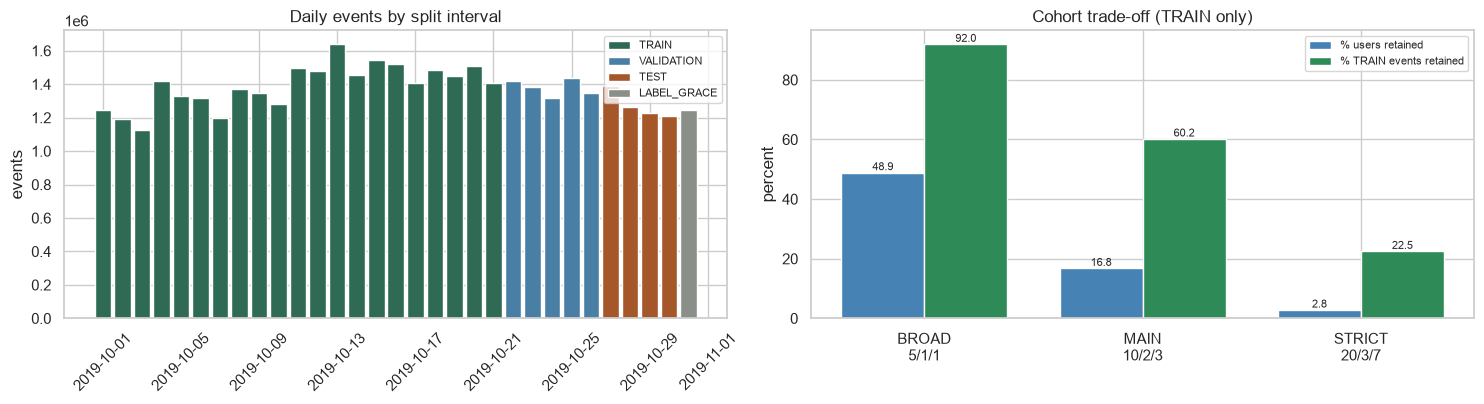

In [17]:
daily = pd.DataFrame(audit["time_coverage"]["daily"]).T
# the audit stores plain dates; the split cutoffs are UTC, so align them before comparing
daily.index = pd.to_datetime(daily.index).tz_localize("UTC")
daily = daily.sort_index()

colours = {"TRAIN": "#2F6B54", "VALIDATION": "#4A7FA5",
           "TEST": "#A6572A", "LABEL_GRACE": "#8A8F87"}

figure, axes = plt.subplots(1, 2, figsize=(15, 4.2))

for name, start, end in SPLITS:
    window = daily[(daily.index >= start) & (daily.index < end)]
    axes[0].bar(window.index, window["events"], color=colours[name], label=name, width=0.85)
axes[0].set_title("Daily events by split interval")
axes[0].set_ylabel("events")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=45)

position = np.arange(len(comparison))
width = 0.38
axes[1].bar(position - width / 2, comparison["user_percent"], width,
            color="steelblue", label="% users retained")
axes[1].bar(position + width / 2, comparison["event_percent"], width,
            color="seagreen", label="% TRAIN events retained")
axes[1].set_xticks(position)
axes[1].set_xticklabels([f"{row.candidate}\n{row.rule}" for row in comparison.itertuples()])
axes[1].set_ylabel("percent")
axes[1].set_title("Cohort trade-off (TRAIN only)")
axes[1].legend(fontsize=8)
for index, row in comparison.iterrows():
    axes[1].text(index - width / 2, row["user_percent"], f"{row['user_percent']:.1f}",
                 ha="center", va="bottom", fontsize=8)
    axes[1].text(index + width / 2, row["event_percent"], f"{row['event_percent']:.1f}",
                 ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 10. Validation

Fourteen checks on the properties that would silently break the science if they were wrong.

In [18]:
checks = []


def validate(name, passed, detail=""):
    checks.append({"check": name, "status": "PASS" if passed else "FAIL", "detail": detail})


validate("input rows reconcile with S1-DS-04", rows_seen == audit_rows,
         f"{rows_seen:,}")
validate("every event lands in exactly one interval", int(split_rows.sum()) == TOTAL_ROWS,
         f"{int(split_rows.sum()):,}")

# an event exactly on a cutoff must fall to the right of it
cutoff = SPLITS[1][1]
probe = pd.Series([cutoff - pd.Timedelta(microseconds=1), cutoff])
probe_codes = assign_split(probe)
validate("an event on a cutoff belongs to the later interval",
         probe_codes[0] == 0 and probe_codes[1] == 1,
         f"{SPLIT_NAMES[probe_codes[0]]} -> {SPLIT_NAMES[probe_codes[1]]}")

# Fixtures prove the behaviour directly instead of inferring it from cardinality.
probe_sessions = pd.DataFrame({
    "user_id": ["1", "2", "3", "3"],
    "user_session": ["shared-raw-id", "shared-raw-id", None, None],
    "source_row_number": [1, 2, 3, 4],
})
probe_keys = logical_session_key(probe_sessions)
validate("same raw session under two users yields two logical sessions",
         probe_keys.iloc[0] != probe_keys.iloc[1])
validate("each null session becomes its own singleton",
         probe_keys.iloc[2] != probe_keys.iloc[3])
validate("null session rows match the audit", null_session_rows == audit_null_sessions,
         f"{null_session_rows} rows")

crossing_fixture = {
    (test_code, grace_code): False,
    (train_code, val_code): True,
    (val_code, test_code): True,
    (train_code, grace_code): True,
    (val_code, grace_code): True,
    (train_code,): False,
}
validate("crossing patterns classify correctly, including reaching into grace",
         all((pattern not in ALLOWED_PATTERNS) == expected
             for pattern, expected in crossing_fixture.items()),
         f"{len(crossing_fixture)} patterns")

validate("cohort statistics use TRAIN rows only",
         int(train_stats["events"].sum()) == int(split_rows[train_code]),
         f"{int(train_stats['events'].sum()):,}")
validate("active days never exceed TRAIN calendar days",
         int(train_stats["active_days"].max()) <= (SPLITS[0][2] - SPLITS[0][1]).days,
         f"max {int(train_stats['active_days'].max())} of {(SPLITS[0][2] - SPLITS[0][1]).days}")
validate("active days never exceed a user's TRAIN events",
         bool((train_stats["active_days"] <= train_stats["events"]).all()))

validate("every excluded session has a disallowed touch pattern",
         bool(session_patterns[session_patterns.index.isin(crossing_sessions)]
              .isin(ALLOWED_PATTERNS).sum() == 0),
         f"{len(crossing_sessions):,} excluded")
validate("label grace starts no decision interval",
         "LABEL_GRACE" not in DECISION_SPLITS)
validate("cohorts are mutually exclusive and cover every user",
         int(cohort_counts["users"].sum()) == len(cohort) == audit_users,
         f"{len(cohort):,}")
validate(f"selected cohort meets the feasibility gate (>= {COHORT_GATE:,})",
         len(c1_users) >= COHORT_GATE, f"{len(c1_users):,}")

validate("every excluded session carries the raw pair a non-pandas lane needs",
         len(excluded_identity_parts) > 0
         and bool(pd.concat(excluded_identity_parts, ignore_index=True)
                  .drop_duplicates(subset=["session_key"])["user_id"].notna().all()),
         f"{len(crossing_sessions):,} sessions")
validate("client density covers every decision split",
         set(client_density["split"]) == set(DECISION_SPLITS),
         ", ".join(client_density["split"]))
validate("client density never reports more clients than the cohort holds",
         bool((client_density["clients_with_data"] <= len(c1_users)).all()),
         f"cohort {len(c1_users):,}")
validate("the cohort rule still holds for almost every client after exclusion",
         cohort_drift["below_rule"] / len(c1_users) < 0.01
         and cohort_drift["with_no_usable_train_events"] == 0,
         f"{cohort_drift['below_rule']:,} below the rule")
validate("the client skew shares form a non-decreasing cumulative series",
         bool(skew["hold_this_share_of_validation_events_%"].is_monotonic_increasing),
         f"top 10% hold "
         f"{skew.loc[2, 'hold_this_share_of_validation_events_%']}%")

results = pd.DataFrame(checks)
print(results.to_string(index=False))

failed = results[results["status"] == "FAIL"]
assert failed.empty, f"validation failed:\n{failed.to_string(index=False)}"
print()
print("Final validation: PASS")

                                                              check status                  detail
                                 input rows reconcile with S1-DS-04   PASS              42,448,764
                          every event lands in exactly one interval   PASS              42,448,764
                 an event on a cutoff belongs to the later interval   PASS     TRAIN -> VALIDATION
       same raw session under two users yields two logical sessions   PASS                        
                        each null session becomes its own singleton   PASS                        
                                  null session rows match the audit   PASS                  2 rows
crossing patterns classify correctly, including reaching into grace   PASS              6 patterns
                              cohort statistics use TRAIN rows only   PASS              29,218,702
                       active days never exceed TRAIN calendar days   PASS            max 21 of 21
          

## 11. Outputs

One compact protocol JSON, and a minimal row-level cohort manifest. The manifest holds
pseudonymous user ids, so it stays internal.

In [19]:
protocol = {
    "status": "PROPOSED",
    "source": {
        "parquet": SOURCE_PARQUET.name,
        "rows": int(TOTAL_ROWS),
        "reconciled_with": "S1-DS-04 data_audit_pass1.json",
    },
    "session_policy": {
        "logical_key": "(user_id, user_session)",
        "provided_sessions": "preserved as supplied by REES46",
        "null_fallback": "one singleton session per row, keyed by provenance",
        "null_rows": int(null_session_rows),
        "logical_sessions": int(len(composite_session_keys)),
        "raw_values_used_by_more_than_one_user": int(reused_raw_keys),
    },
    "temporal_split": {
        name: {"start": str(start), "end_exclusive": str(end),
               "days": (end - start).days,
               "events": int(split_rows[index]),
               "percent": round(float(split_rows[index]) / TOTAL_ROWS * 100, 2),
               "decisions": name in DECISION_SPLITS}
        for index, (name, start, end) in enumerate(SPLITS)
    },
    "boundary_policy": {
        "rule": "exclude the whole logical session when it crosses TRAIN/VALIDATION "
                "or VALIDATION/TEST",
        "test_to_grace": "not a crossing; a test session may mature into label grace",
        "crossing_sessions": int(len(crossing_sessions)),
        "identity_artifact": "INTERNAL_DO_NOT_UPLOAD_excluded_sessions_v1.proposed.parquet",
        "identity_note": "downstream tasks must read this list instead of recomputing it, "
                         "because recomputing requires reading intervals they must not read",
        "crossing_percent": round(len(crossing_sessions) / total_sessions * 100, 4),
        "train_events_excluded": int(excluded_train_events),
        "train_events_excluded_percent": round(
            excluded_train_events / int(train_stats["events"].sum()) * 100, 3),
        "selected_users_touched": int(len(affected_c1)),
    },
    "client_density": {
        "unit": "one client is one user; counts are post-exclusion",
        "why": "the regimes are compared per client, so a cohort median does not say "
               "whether an individual client can be trained or scored",
        "per_split": client_density.to_dict(orient="records"),
        "clients_with_no_validation_data": int((validation_events == 0).sum()),
        "evaluable_under_a_minimum_rule": evaluable.to_dict(orient="records"),
        "minimum_rule_status": "NOT DECIDED - S1-DS-09 owns it",
    },
    "client_skew": {
        "validation_events_held_by_largest_clients": skew.to_dict(orient="records"),
        "consequence": "macro and micro averages will not agree; FedAvg weights clients "
                       "by sample count, so the same skew decides how much of the "
                       "federated model comes from how few devices",
        "averaging_convention": "NOT DECIDED - S1-DS-09 owns it",
    },
    "cohort_rule_after_exclusion": dict(
        cohort_drift,
        note="recorded, not acted on; dropping these clients would make membership "
             "depend on crossing status, which is future-derived"),
    "cohort_policy": {
        "basis": "TRAIN interval only",
        "active_days": "distinct calendar dates with at least one event",
        "elapsed_span_used": False,
        "candidates": candidates,
        "selected": SELECTED,
    },
    "cohort_results": comparison.to_dict(orient="records"),
    "purchase_diagnostic": purchase_diagnostic.to_dict(orient="records"),
    "feasibility_gate": {
        "min_c1_users": int(COHORT_GATE),
        "selected_c1_users": int(len(c1_users)),
        "status": "PASS" if len(c1_users) >= COHORT_GATE else "FAIL",
    },
    "cohort_counts": {
        name: {"users": int(row["users"]), "percent": float(row["percent"])}
        for name, row in cohort_counts.iterrows()
    },
    "train_user_distribution": {
        column: {row: float(percentiles.loc[row, column]) for row in percentiles.index}
        for column in percentiles.columns
    },
    "totals": {
        "users": int(len(cohort)),
        "users_in_train": int(len(train_stats)),
        "train_events": int(train_stats["events"].sum()),
        "logical_sessions": int(len(composite_session_keys)),
        "raw_session_values": int(raw_session_keys),
        "raw_values_used_by_more_than_one_user": int(reused_raw_keys),
    },
    "censoring": {
        "rule": "an outcome that is not yet observable is censored, never a negative label",
        "representation": "label = null, task_mask = false, status = CENSORED",
        "owner": "TaskExample builders define label_matures_at per task",
    },
    "validation": checks,
    "handoff": {
        "canonical_order": ["event_time", "source_row_number"],
        "known_downstream_constraints": {
            "T1": [
                "not every session contains a usable sequence",
                "canonical order is (event_time, source_row_number)",
                "history must stop before the target decision",
            ],
            "T2": [
                "the session-level purchase rate from S1-DS-04 is not the T2 positive rate",
                "count eligible decision points after session, split and censoring rules",
                "an unmatured outcome is censored, never negative",
            ],
            "T3": [
                "REES46 has no remove_from_cart event; no rule may assume one",
                "cart frequency shifts across the month, so report gain distribution by split",
                "candidate generation and gain semantics are separate downstream decisions",
            ],
        },
        "next_task": "TaskExample builders (T1/T2/T3)",
        "receives": ["cohort membership", "split intervals", "session policy",
                     "the excluded-session identity list", "censoring rule",
                     "canonical ordering"],
    },
}

protocol_path = OUTPUT_DIR / "data_protocol_v1.proposed.json"
protocol_path.write_text(json.dumps(protocol, indent=2), encoding="utf-8")

manifest = pd.DataFrame({"user_id": cohort.index, "cohort": cohort.to_numpy()})
manifest_path = OUTPUT_DIR / "INTERNAL_DO_NOT_UPLOAD_cohort_manifest_v1.proposed.parquet"
manifest.to_parquet(manifest_path, index=False)

# The identities of the excluded sessions, not only their count. Without this a later
# task cannot apply the boundary rule without re-reading intervals it must not read:
# deciding whether a VALIDATION session crosses into TEST requires seeing TEST rows.
# Publishing the list here keeps that lookup inside the task that owns the rule.
excluded = (pd.concat(excluded_identity_parts, ignore_index=True)
            .drop_duplicates(subset=["session_key"])
            .sort_values("session_key")
            .reset_index(drop=True))
excluded["touch_pattern"] = excluded["session_key"].map(readable)
# The raw pair travels with the hash. A 64-bit pandas hash is only reproducible by code
# that repeats this notebook's dtype pipeline exactly, and the other lanes write their own
# implementations. Without (user_id, user_session) they cannot apply the rule at all: they
# would derive different keys, match nothing, and conclude there is no leakage to remove.
excluded = excluded[["session_key", "user_id", "user_session", "touch_pattern"]]
excluded_path = OUTPUT_DIR / "INTERNAL_DO_NOT_UPLOAD_excluded_sessions_v1.proposed.parquet"
excluded.to_parquet(excluded_path, index=False)

assert manifest["user_id"].is_unique, "cohort manifest has duplicate users"
assert len(manifest) == audit_users, "cohort manifest does not cover every user"
assert len(excluded) == len(crossing_sessions), "excluded session list is incomplete"
assert excluded["session_key"].is_unique, "excluded session list has duplicates"
assert excluded["user_id"].notna().all(), "an excluded session has no owning user"

for path in [protocol_path, manifest_path, excluded_path]:
    print(f"{path.name:56} {path.stat().st_size / 1024:8.1f} KB")

data_protocol_v1.proposed.json                               12.0 KB
INTERNAL_DO_NOT_UPLOAD_cohort_manifest_v1.proposed.parquet  13742.8 KB
INTERNAL_DO_NOT_UPLOAD_excluded_sessions_v1.proposed.parquet    269.1 KB


In [20]:
print(f"Final validation: PASS")
print(f"Protocol status: {protocol['status']}")
print(f"Selected cohort candidate: {SELECTED} "
      f"({selected_rule['min_events']} events, {selected_rule['min_sessions']} sessions, "
      f"{selected_rule['min_active_days']} active days)")
print(f"C1 users: {len(c1_users):,}")
print(f"Next owner: TaskExample builders (T1/T2/T3)")

Final validation: PASS
Protocol status: PROPOSED
Selected cohort candidate: MAIN (10 events, 2 sessions, 3 active days)
C1 users: 388,789
Next owner: TaskExample builders (T1/T2/T3)


## What the next task receives

| Handed over | Value |
|---|---|
| Canonical order | `(event_time, source_row_number)` |
| Split intervals | four half-open UTC windows, grace is observation only |
| Session policy | `(user_id, user_session)`, provided sessions preserved |
| Boundary rule | whole session excluded when it crosses a decision cutoff |
| Censoring rule | unobservable outcome is censored, never a negative |
| Cohort membership | `C1` / `C2` / `C3_VAL` / `C3_TEST` / `GRACE_ONLY` |

## Still open

Client assignment into train/dev/final groups, `T1` target semantics, `T2` first-view label
construction, and the `T3` candidate and gain protocol. None of them are decided here.